In [4]:
import torch
from torch import nn
from d2l import torch as d2l

class Reshape(torch.nn.Module):
    def forward(self, x):
        return x.view(-1, 1, 28, 28)

net = torch.nn.Sequential(
    Reshape(),
    nn.Conv2d(1, 6, kernel_size=5, padding=2),   # Conv1: 1→6通道
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),        # Pool1: 28→14
    nn.Conv2d(6, 16, kernel_size=5),              # Conv2: 6→16通道
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),        # Pool2: 14→7
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120),                   # FC1
    nn.Sigmoid(),
    nn.Linear(120, 84),                           # FC2
    nn.Sigmoid(),
    nn.Linear(84, 10)                             # 输出层(10个类别)
)

In [5]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
print("输入形状:", X.shape)
print("-" * 40)
    
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, "输出形状:", X.shape)

输入形状: torch.Size([1, 1, 28, 28])
----------------------------------------
Reshape 输出形状: torch.Size([1, 1, 28, 28])
Conv2d 输出形状: torch.Size([1, 6, 28, 28])
Sigmoid 输出形状: torch.Size([1, 6, 28, 28])
AvgPool2d 输出形状: torch.Size([1, 6, 14, 14])
Conv2d 输出形状: torch.Size([1, 16, 10, 10])
Sigmoid 输出形状: torch.Size([1, 16, 10, 10])
AvgPool2d 输出形状: torch.Size([1, 16, 5, 5])
Flatten 输出形状: torch.Size([1, 400])
Linear 输出形状: torch.Size([1, 120])
Sigmoid 输出形状: torch.Size([1, 120])
Linear 输出形状: torch.Size([1, 84])
Sigmoid 输出形状: torch.Size([1, 84])
Linear 输出形状: torch.Size([1, 10])


In [6]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的精度。"""
    if isinstance(net, torch.nn.Module):
        net.eval()                          # 切换到评估模式
    
    if not device:
        device = next(iter(net.parameters())).device  # 自动获取设备
    
    metric = d2l.Accumulator(2)             # [正确数, 总样本数]
    
    for X, y in data_iter:
        if isinstance(X, list):
            X = [x.to(device) for x in X]   # 多个输入的情况
        else:
            X = X.to(device)                # 单个输入，移到GPU
        y = y.to(device)                    # 标签移到GPU
        
        metric.add(d2l.accuracy(net(X), y), y.numel())
    
    return metric[0] / metric[1]            # 返回准确率

In [7]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """在GPU上训练模型"""
    
    # ========== 1. 参数初始化 ==========
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    
    # ========== 2. 训练准备 ==========
    print('training on', device)
    net.to(device)                          # 将模型移到GPU
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)  # 优化器
    loss = nn.CrossEntropyLoss()            # 损失函数
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc'])  # 可视化
    timer, num_batches = d2l.Timer(), len(train_iter)
    
    # ========== 3. 训练循环 ==========
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)         # 累加器：[损失和, 正确数, 样本总数]
        net.train()                         # 切换到训练模式
        
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            
            # 前向传播
            optimizer.zero_grad()           # 梯度清零
            X, y = X.to(device), y.to(device)  # 数据移到GPU
            y_hat = net(X)                  # 预测
            l = loss(y_hat, y)              # 计算损失
            
            # 反向传播
            l.backward()                    # 计算梯度
            optimizer.step()                # 更新参数
            
            # 记录指标
            metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            
            # 计算当前进度
            train_l = metric[0] / metric[2]   # 平均损失
            train_acc = metric[1] / metric[2] # 平均准确率
            
            # 每完成1/5个epoch时更新动画
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (train_l, train_acc, None))
        
        # ========== 4. 每个epoch结束后测试 ==========
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    
    # ========== 5. 输出结果 ==========
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(device)}')

In [8]:

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=64)

loss 0.339, train acc 0.875, test acc 0.861
28799.3 examples/sec on cuda:0


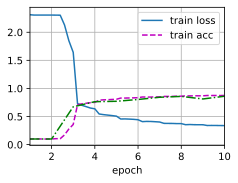

In [9]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())